# CIFAKE Grad-CAM Visualization

Generates Grad-CAM heatmaps that highlight **which regions** the model focuses on when classifying Real vs AI-generated images.

- Target layer: `conv2d_4` (last convolutional layer before GlobalAveragePooling)
- Shows REAL and FAKE examples side-by-side
- No OpenCV dependency — uses scipy + matplotlib only

## 1. Imports & Config

In [1]:
%pip install numpy matplotlib tensorflow scikit-learn pillow scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## 2. Paths & Load Model

In [3]:
PROJECT_ROOT = Path('../')
DATASET_DIR  = PROJECT_ROOT / 'dataset'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'
HEATMAPS_DIR = OUTPUTS_DIR / 'heatmaps'
HEATMAPS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 32
REAL_DIR   = DATASET_DIR / 'REAL'
FAKE_DIR   = DATASET_DIR / 'FAKE'

# Auto-detect saved format
MODEL_PATH = MODELS_DIR / 'best_model.keras'
if not MODEL_PATH.exists():
    MODEL_PATH = MODELS_DIR / 'best_model.hdf5'

print(f"Loading model: {MODEL_PATH}")
model = keras.models.load_model(str(MODEL_PATH))
print("✓ Model loaded")

# Print layer names to confirm target
print("\nConvolutional layers:")
for layer in model.layers:
    if 'conv2d' in layer.name:
        print(f"  {layer.name}")

Loading model: ../models/best_model.keras
✓ Model loaded

Convolutional layers:
  conv2d
  conv2d_1
  conv2d_2
  conv2d_3
  conv2d_4


## 3. Grad-CAM Implementation

In [4]:
# Sequential models in Keras 3 don't expose layer.output directly, so we
# reconstruct the computation graph functionally by threading an Input through
# each layer. We capture the last Conv2D output before GlobalAveragePooling.

def build_gradcam_model(model):
    """
    Rebuild model as Functional graph, capturing the last Conv2D output
    that appears before GlobalAveragePooling.
    Returns: (grad_model, layer_name)
    """
    inp = keras.Input(shape=(32, 32, 3))
    x = inp
    conv_captured = None
    last_conv_name = None
    hit_gap = False
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, keras.layers.Conv2D) and not hit_gap:
            conv_captured = x
            last_conv_name = layer.name
        if isinstance(layer, keras.layers.GlobalAveragePooling2D):
            hit_gap = True  # stop updating conv_captured after this point
    return keras.Model(inputs=inp, outputs=[conv_captured, x]), last_conv_name

grad_model, GRADCAM_LAYER = build_gradcam_model(model)
print(f"Grad-CAM target layer : {GRADCAM_LAYER}")
print(f"Conv output shape     : {grad_model.outputs[0].shape}")
print("✓ Grad-CAM sub-model built")

Grad-CAM target layer : conv2d_4
Conv output shape     : (None, 8, 8, 64)
✓ Grad-CAM sub-model built


In [5]:
def generate_gradcam(img_array, target_class=None):
    """
    Compute Grad-CAM heatmap for a single image.

    Args:
        img_array : (32, 32, 3) float32 in [0, 1]
        target_class : 0=REAL, 1=FAKE, None=use predicted class

    Returns:
        heatmap     : (32, 32) float in [0, 1]  — upsampled to image size
        pred_class  : int
        pred_conf   : float
    """
    inp = tf.cast(np.expand_dims(img_array, 0), tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inp)
        conv_outputs, predictions = grad_model(inp, training=False)
        pred_class = int(tf.argmax(predictions[0]))
        pred_conf  = float(predictions[0][pred_class])
        cls = target_class if target_class is not None else pred_class
        score = predictions[:, cls]

    # Gradients of score w.r.t. the conv feature maps
    grads = tape.gradient(score, conv_outputs)          # (1, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    # Weight feature maps by their pooled gradients
    conv_out = conv_outputs[0]                          # (H, W, C)
    heatmap  = tf.reduce_sum(conv_out * pooled_grads, axis=-1)  # (H, W)

    # ReLU + normalize to [0, 1]
    heatmap = tf.nn.relu(heatmap).numpy()
    max_val = heatmap.max()
    if max_val > 0:
        heatmap = heatmap / max_val

    # Upsample from (8, 8) → (32, 32) using scipy zoom
    h, w = img_array.shape[:2]
    zoom_factors = (h / heatmap.shape[0], w / heatmap.shape[1])
    heatmap = zoom(heatmap, zoom_factors, order=1)
    heatmap = np.clip(heatmap, 0, 1)

    return heatmap, pred_class, pred_conf


def apply_heatmap_overlay(img, heatmap, alpha=0.45, colormap='jet'):
    """
    Blend a heatmap over the original image using matplotlib colormap.
    No OpenCV required.
    """
    cmap   = plt.get_cmap(colormap)
    colored = cmap(heatmap)[:, :, :3]          # (H, W, 3) RGB in [0,1]
    overlay = (1 - alpha) * img + alpha * colored
    return np.clip(overlay, 0, 1)


print("✓ generate_gradcam and apply_heatmap_overlay defined")

✓ generate_gradcam and apply_heatmap_overlay defined


## 4. Sample Images from Dataset

In [6]:
def load_sample_images(directory, n=10, image_size=32):
    """Load n random images from a directory."""
    files = [f for f in os.listdir(str(directory))
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    np.random.shuffle(files)
    images = []
    for fname in files[:n]:
        img = keras.preprocessing.image.load_img(
            os.path.join(str(directory), fname),
            target_size=(image_size, image_size)
        )
        images.append(keras.preprocessing.image.img_to_array(img) / 255.0)
    return np.array(images)

N_SAMPLES = 5   # samples per class to visualise

print("Loading sample REAL images...")
real_samples = load_sample_images(REAL_DIR, n=N_SAMPLES)
print(f"  Loaded: {real_samples.shape}")

print("Loading sample FAKE images...")
fake_samples = load_sample_images(FAKE_DIR, n=N_SAMPLES)
print(f"  Loaded: {fake_samples.shape}")

Loading sample REAL images...
  Loaded: (5, 32, 32, 3)
Loading sample FAKE images...
  Loaded: (5, 32, 32, 3)


## 5. Grad-CAM Grid — REAL vs FAKE

/var/folders/p2/xtdxcz3s5g713z1mf9qywjpm0000gn/T/ipykernel_14196/2887630387.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


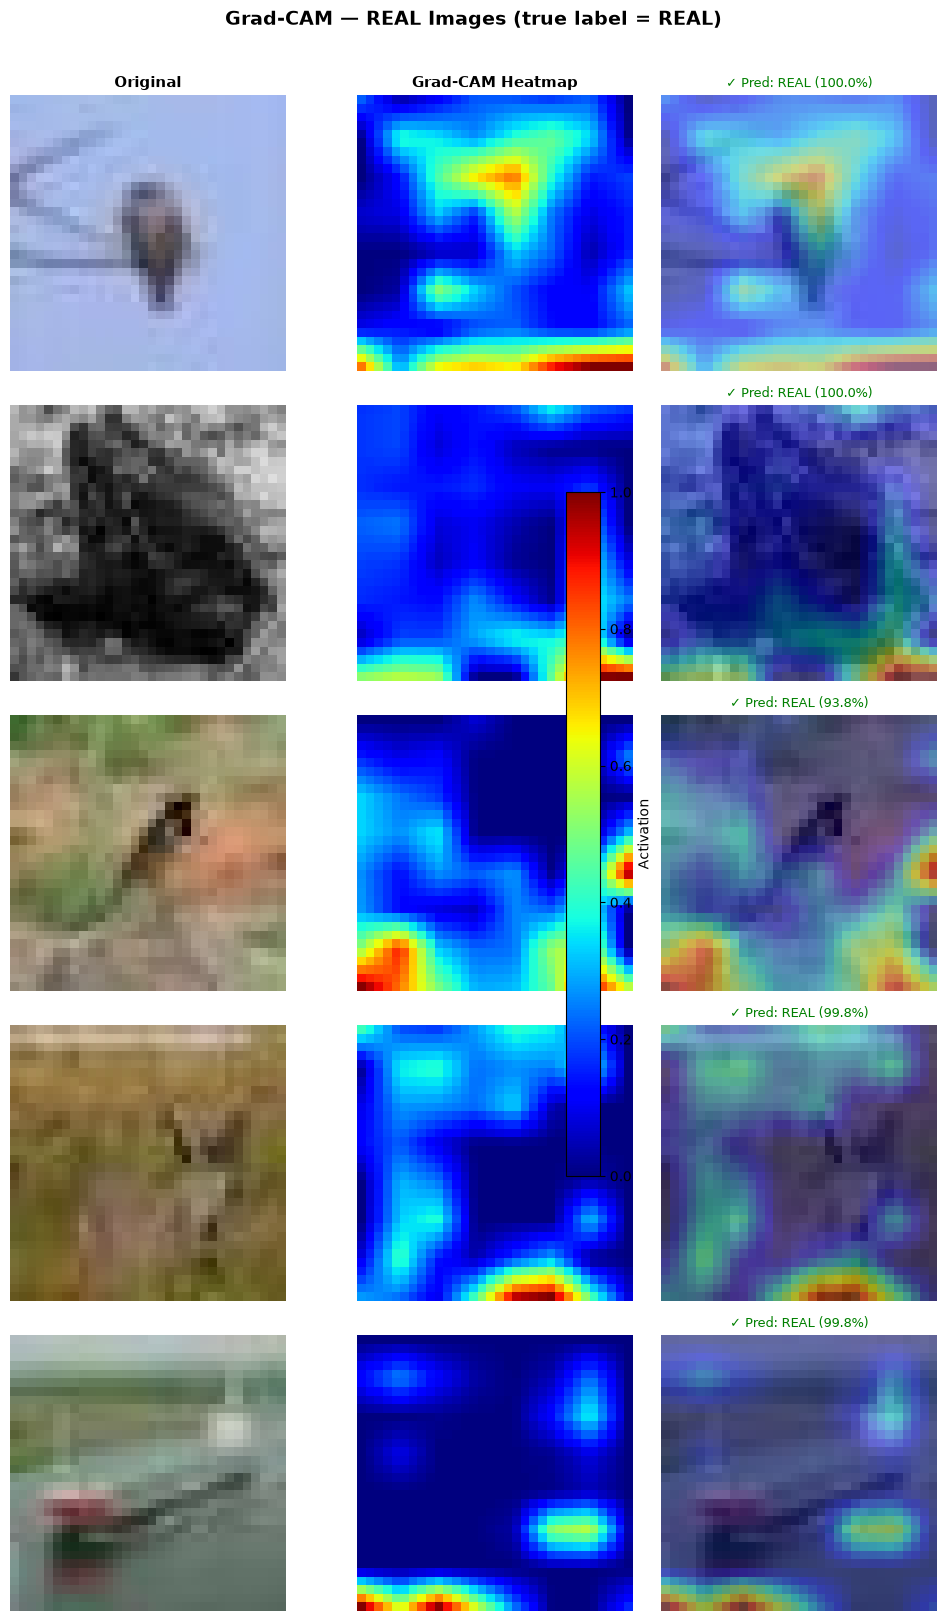

✓ Saved: ../outputs/heatmaps/gradcam_real.png


In [7]:
CLASS_NAMES = ['REAL', 'FAKE']
CLASS_COLORS = {'REAL': 'green', 'FAKE': 'red'}

def plot_gradcam_grid(samples, true_label, title, save_path):
    """
    Plot a grid of: Original | Heatmap | Overlay  for each sample.
    """
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.2))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    col_titles = ['Original', 'Grad-CAM Heatmap', 'Overlay']
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=11, fontweight='bold')

    for row, img in enumerate(samples):
        heatmap, pred_class, pred_conf = generate_gradcam(img)
        overlay = apply_heatmap_overlay(img, heatmap)

        label_str   = CLASS_NAMES[pred_class]
        label_color = CLASS_COLORS[label_str]
        correct     = '✓' if pred_class == true_label else '✗'

        axes[row, 0].imshow(img)
        axes[row, 0].set_ylabel(f'Sample {row+1}', fontsize=9)
        axes[row, 0].axis('off')

        im = axes[row, 1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f'{correct} Pred: {label_str} ({pred_conf:.1%})',
            fontsize=9, color=label_color
        )
        axes[row, 2].axis('off')

    # Shared colorbar for heatmaps column
    fig.colorbar(im, ax=axes[:, 1].tolist(), shrink=0.6, label='Activation')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_path}")


# --- REAL images ---
plot_gradcam_grid(
    real_samples, true_label=0,
    title='Grad-CAM — REAL Images (true label = REAL)',
    save_path=HEATMAPS_DIR / 'gradcam_real.png'
)

/var/folders/p2/xtdxcz3s5g713z1mf9qywjpm0000gn/T/ipykernel_14196/2887630387.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


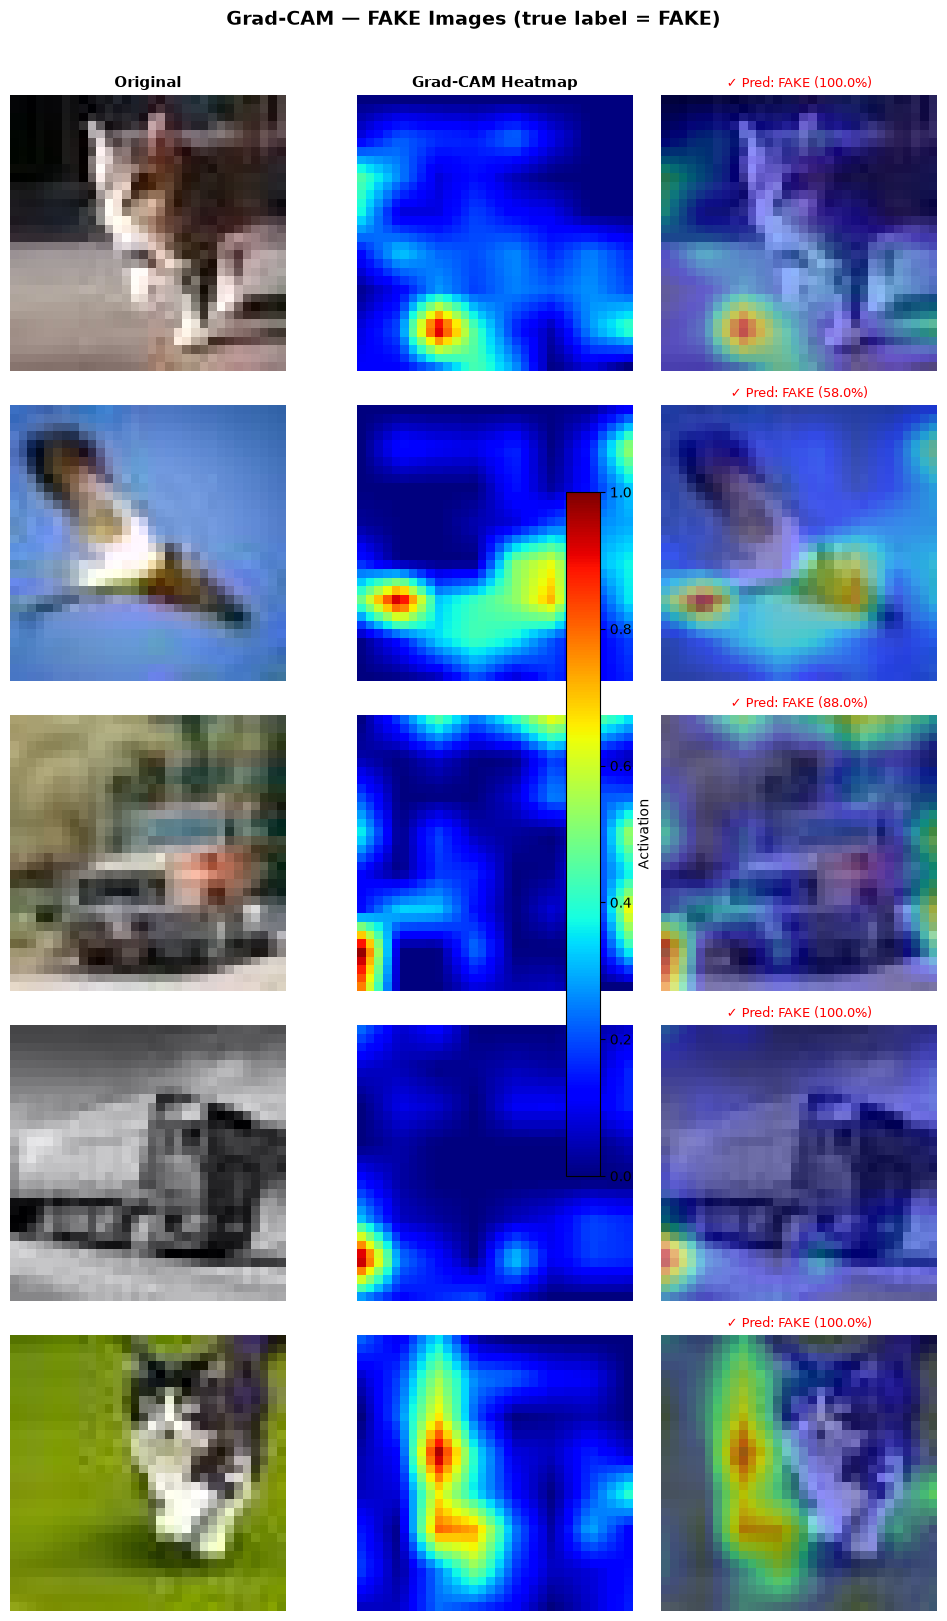

✓ Saved: ../outputs/heatmaps/gradcam_fake.png


In [8]:
# --- FAKE images ---
plot_gradcam_grid(
    fake_samples, true_label=1,
    title='Grad-CAM — FAKE Images (true label = FAKE)',
    save_path=HEATMAPS_DIR / 'gradcam_fake.png'
)

## 6. Side-by-Side Comparison: REAL vs FAKE

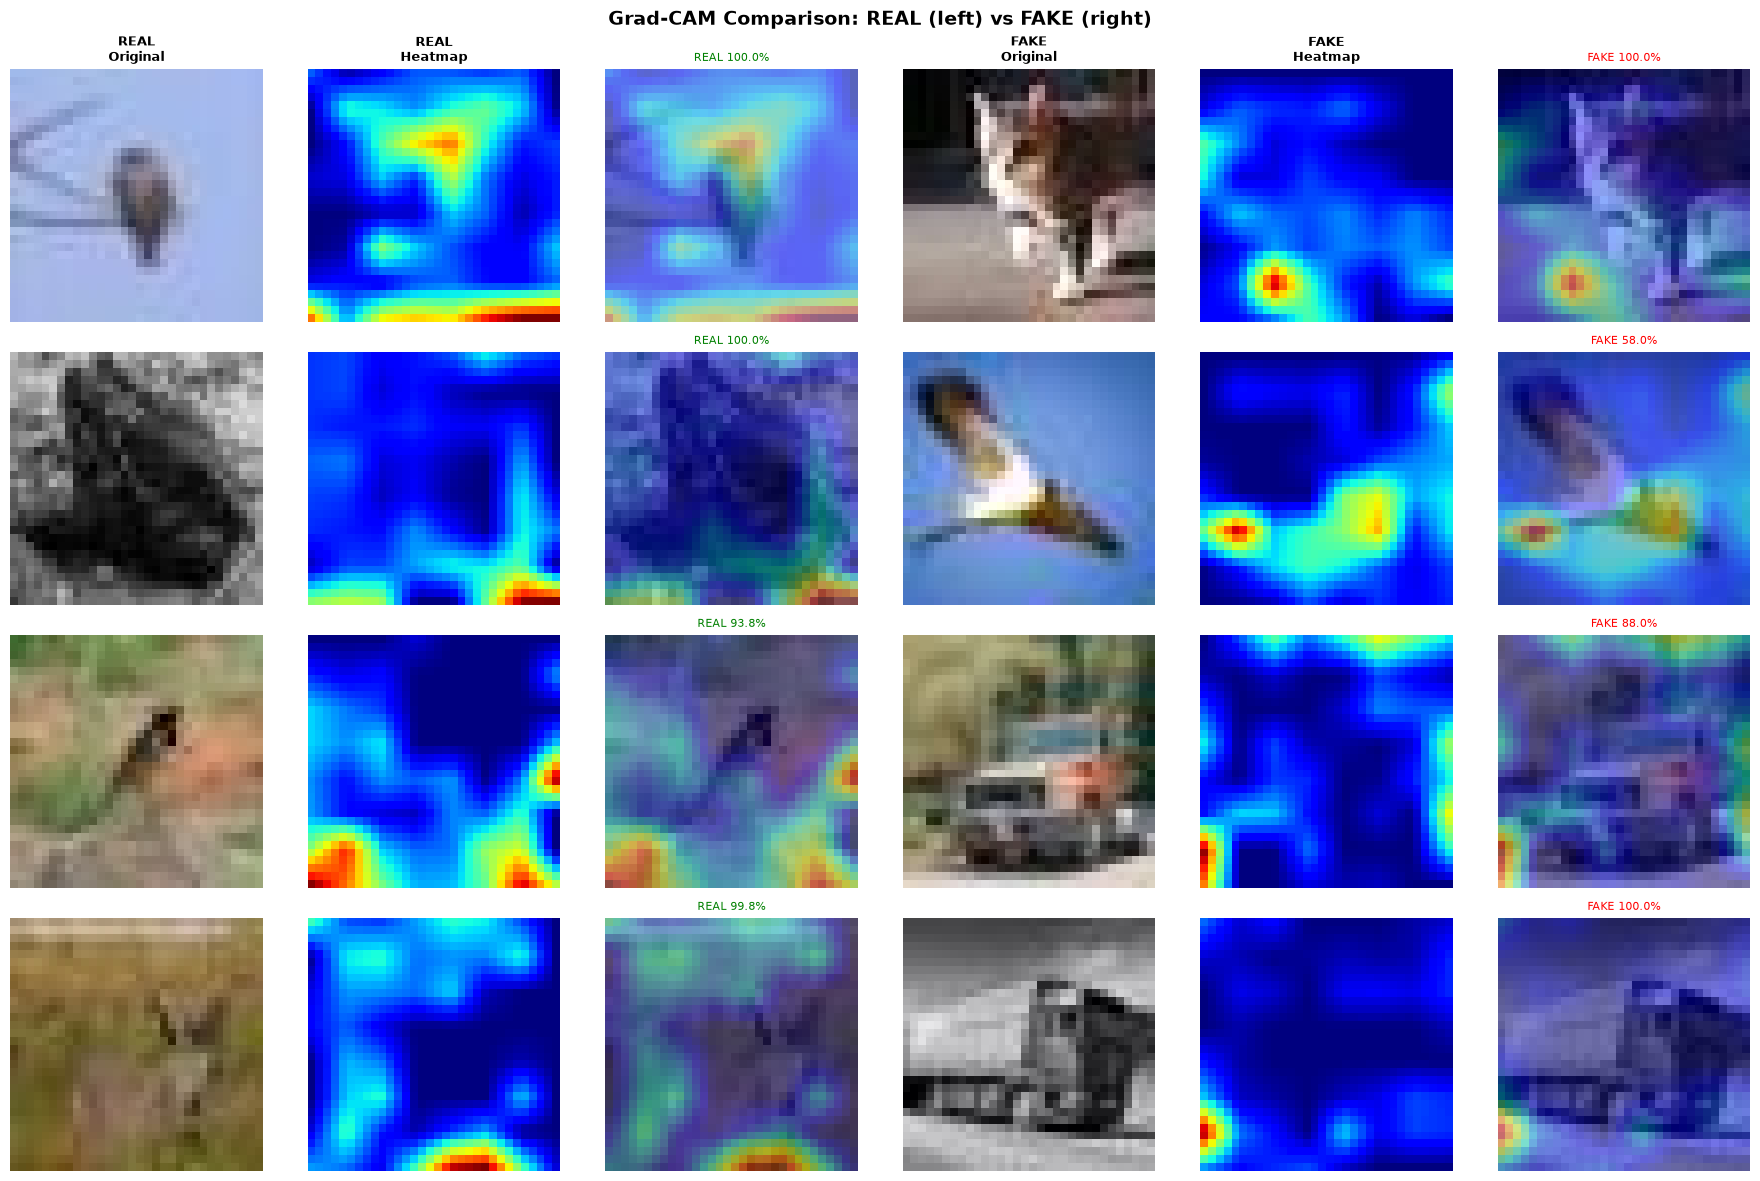

✓ Saved: ../outputs/heatmaps/gradcam_comparison.png


In [9]:
# Pick 4 pairs and show them in one compact comparison figure
N_PAIRS = 4
fig, axes = plt.subplots(N_PAIRS, 6, figsize=(18, N_PAIRS * 3))
fig.suptitle('Grad-CAM Comparison: REAL (left) vs FAKE (right)', fontsize=14, fontweight='bold')

col_headers = ['REAL\nOriginal', 'REAL\nHeatmap', 'REAL\nOverlay',
               'FAKE\nOriginal', 'FAKE\nHeatmap', 'FAKE\nOverlay']
for ax, h in zip(axes[0], col_headers):
    ax.set_title(h, fontsize=9, fontweight='bold')

for i in range(N_PAIRS):
    r_img = real_samples[i]
    f_img = fake_samples[i]

    r_heat, r_pred, r_conf = generate_gradcam(r_img)
    f_heat, f_pred, f_conf = generate_gradcam(f_img)

    r_overlay = apply_heatmap_overlay(r_img, r_heat)
    f_overlay = apply_heatmap_overlay(f_img, f_heat)

    for j, (data, cmap) in enumerate([
        (r_img,     None),
        (r_heat,    'jet'),
        (r_overlay, None),
        (f_img,     None),
        (f_heat,    'jet'),
        (f_overlay, None),
    ]):
        ax = axes[i, j]
        if cmap:
            ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(data)
        ax.axis('off')

    # Annotate overlay predictions
    axes[i, 2].set_title(f"{CLASS_NAMES[r_pred]} {r_conf:.1%}",
                          fontsize=8, color=CLASS_COLORS[CLASS_NAMES[r_pred]])
    axes[i, 5].set_title(f"{CLASS_NAMES[f_pred]} {f_conf:.1%}",
                          fontsize=8, color=CLASS_COLORS[CLASS_NAMES[f_pred]])

plt.tight_layout()
save_path = HEATMAPS_DIR / 'gradcam_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

## 7. Summary

In [10]:
# Quick accuracy check on all samples shown
all_samples = np.concatenate([real_samples, fake_samples])
all_labels  = np.array([0]*N_SAMPLES + [1]*N_SAMPLES)

preds = model.predict(all_samples, verbose=0)
pred_classes = np.argmax(preds, axis=1)
acc = (pred_classes == all_labels).mean()

print(f"Accuracy on displayed samples: {acc:.1%} ({int(acc*len(all_labels))}/{len(all_labels)})")
print(f"""
✓ Grad-CAM analysis complete!

📁 Saved to outputs/heatmaps/:
  - gradcam_real.png        (REAL images grid)
  - gradcam_fake.png        (FAKE images grid)
  - gradcam_comparison.png  (REAL vs FAKE side-by-side)

📌 Grad-CAM layer: {GRADCAM_LAYER}
   Highlights regions with highest gradient activation
   for the predicted class. Red = high attention, Blue = low.
""")

Accuracy on displayed samples: 100.0% (10/10)

✓ Grad-CAM analysis complete!

📁 Saved to outputs/heatmaps/:
  - gradcam_real.png        (REAL images grid)
  - gradcam_fake.png        (FAKE images grid)
  - gradcam_comparison.png  (REAL vs FAKE side-by-side)

📌 Grad-CAM layer: conv2d_4
   Highlights regions with highest gradient activation
   for the predicted class. Red = high attention, Blue = low.

